Step size: 0.01
Solution may not be entierly stable
Step size: 0.1
Solution may not be entierly stable
Step size: 0.5
Solution may not be entierly stable
Step size: 1.0
Solution may not be entierly stable


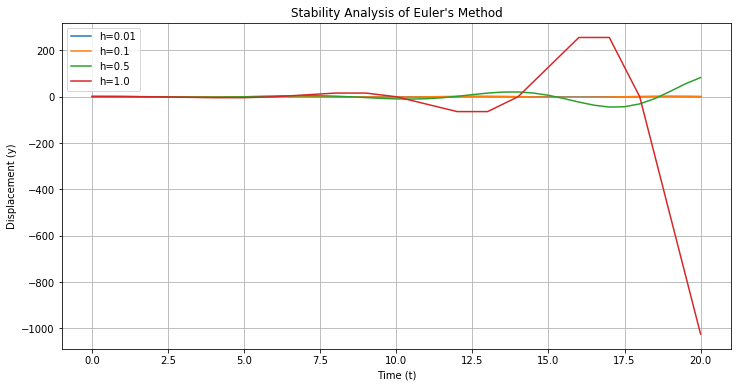

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 1.0 # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0] # Different step sizes to test stability
t_start = 0 # Start time
t_end = 20 # End time
y_0 = 1.0 # Initial displacement
v_0 = 0.0 # Initial velocity

def check_stability_and_plot(h, k, t_start, t_end, y_0, v_0):
    #construct the coefficient matrix
    A = ([[1, h],
         [-h*k, 1]])
    
    #compute eigenvalues and if unstable
    eigenvalues = np.linalg.eigvals(A)
    max_eigen_mag = np.max(np.abs(eigenvalues))
    
    print(f'Step size: {h}')
    if max_eigen_mag <= 1:
        print("Solution is stable")
    else:
        print("Solution may not be entierly stable")
        
    #simulate numerical solution
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    
    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * v_values[i-1]
        v_values[i] = v_values[i-1] + h * (-k * y_values[i-1])
        
    return t_values, y_values

plt.figure(figsize=(12, 6))
for h in h_values:
    t, y = check_stability_and_plot(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'h={h}')

plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()